In [1]:
import sys
sys.path.append('..')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from config import TRAIN_DIR, VALID_DIR, TEST_DIR, IMG_SIZE
from src.dataset import dataset_stats

In [2]:
print("Dataset counts")
for split_name, folder in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    counts = dataset_stats(folder)
    print(f"{split_name}: {counts}")

Dataset counts
train: {'REAL': 45000, 'FAKE': 45000}
valid: {'REAL': 5000, 'FAKE': 5000}
test: {'REAL': 10000, 'FAKE': 10000}


In [3]:
def display_sample_images(folder, label, n=3):
    image_paths = sorted((Path(folder) / label).glob("*.png"))[:n]
    image_paths += sorted((Path(folder) / label).glob("*.jpg"))[:n]
    fig, axes = plt.subplots(1, min(n, len(image_paths)), figsize=(4 * min(n, len(image_paths)), 4))
    if min(n, len(image_paths)) == 1:
        axes = [axes]
    for ax, path in zip(axes, image_paths):
        image = Image.open(path).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"{label} sample")
    plt.show()


Train REAL samples


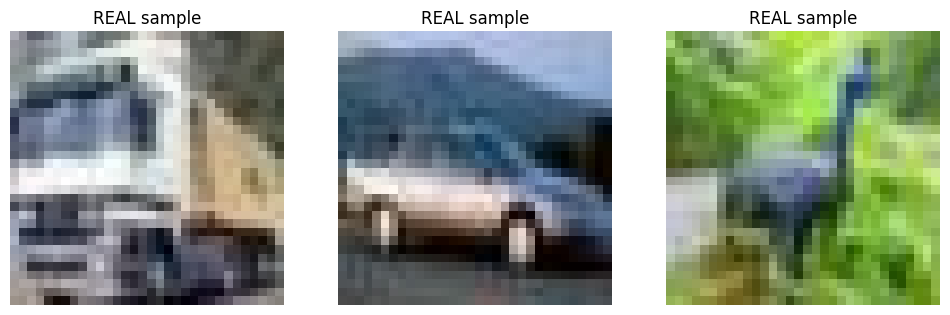

Train FAKE samples


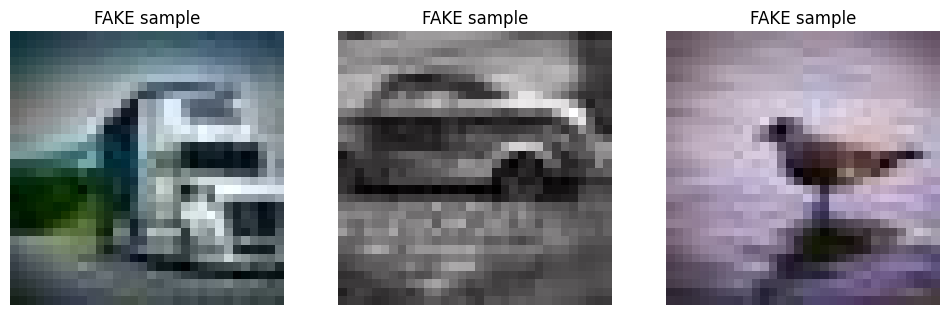

In [4]:
print("\nTrain REAL samples")
display_sample_images(TRAIN_DIR, "REAL")
print("Train FAKE samples")
display_sample_images(TRAIN_DIR, "FAKE")

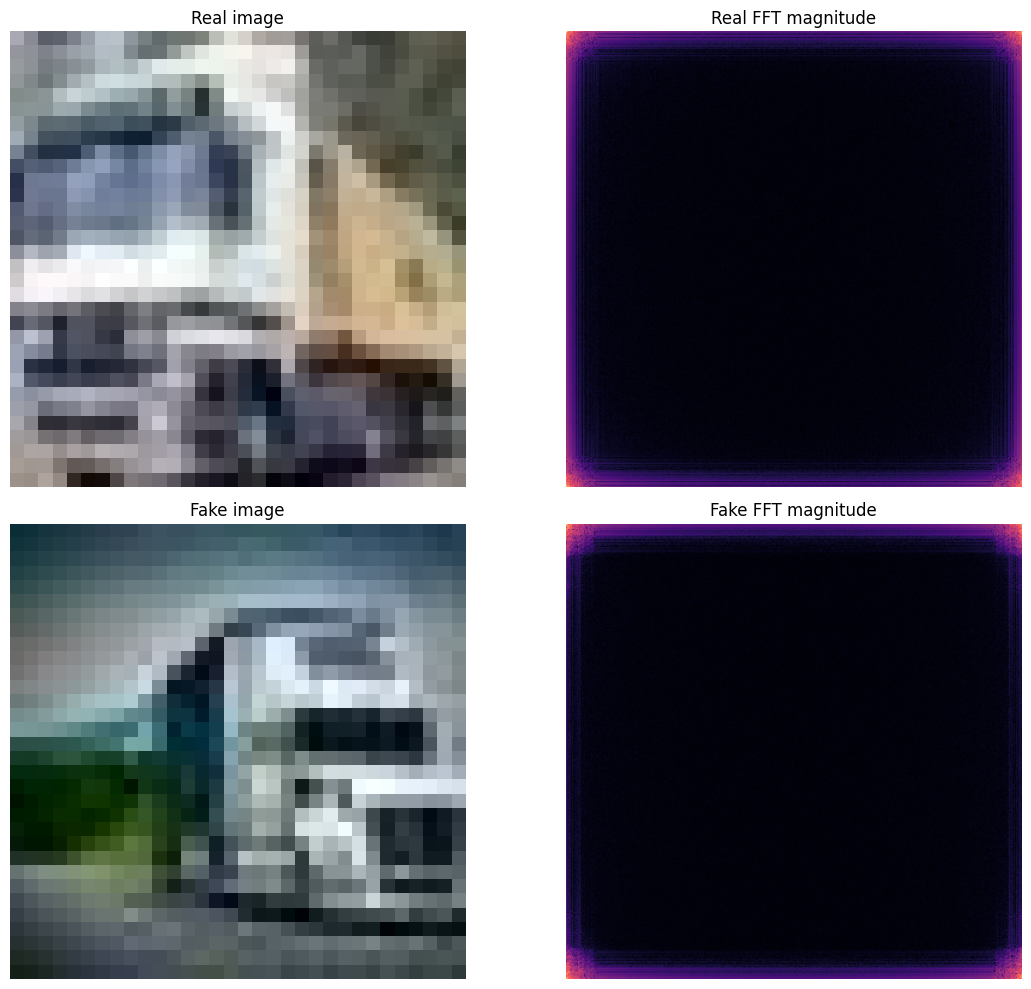

In [5]:
def fft_magnitude(image: Image.Image):
    arr = np.array(image.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    fft = np.fft.fft2(arr, axes=(0, 1))
    magnitude = np.log1p(np.abs(fft))
    return magnitude.mean(axis=2)

real_path = next(Path(TRAIN_DIR / "REAL").glob("*.png"), None) or next(Path(TRAIN_DIR / "REAL").glob("*.jpg"), None)
fake_path = next(Path(TRAIN_DIR / "FAKE").glob("*.png"), None) or next(Path(TRAIN_DIR / "FAKE").glob("*.jpg"), None)

if real_path is not None and fake_path is not None:
    real_image = Image.open(real_path).convert("RGB")
    fake_image = Image.open(fake_path).convert("RGB")
    real_fft = fft_magnitude(real_image)
    fake_fft = fft_magnitude(fake_image)

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs[0, 0].imshow(real_image)
    axs[0, 0].set_title("Real image")
    axs[0, 0].axis("off")
    axs[0, 1].imshow(real_fft, cmap="magma")
    axs[0, 1].set_title("Real FFT magnitude")
    axs[0, 1].axis("off")
    axs[1, 0].imshow(fake_image)
    axs[1, 0].set_title("Fake image")
    axs[1, 0].axis("off")
    axs[1, 1].imshow(fake_fft, cmap="magma")
    axs[1, 1].set_title("Fake FFT magnitude")
    axs[1, 1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No sample images found for FFT comparison.")